# Sustainabilty models

In [ ]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree

# ============================================================
# SETTINGS
# ============================================================

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-3-0_dataframe.csv",
    "embeddings_file": "llm_sustainability_strict_v1-1-0_embeddings.npy",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]
EMBEDDINGS_PATH = CONFIG["features_dir"] / CONFIG["embeddings_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)

INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-3-0_dataframe.csv
EMBEDDINGS_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_embeddings.npy


c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def load_emb(EMBEDDINGS_PATH):
    with Path(EMBEDDINGS_PATH).open("rb") as file:
        return np.load(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [ ]:
# ----------------------------
# LOAD DATA
# ----------------------------

embeddings = load_emb(EMBEDDINGS_PATH)

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
Exists: True
Shape: (46429, 37)
Embeddings shape: (46429, 384)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,...,topic_cat,target_cost,log_target_cost,target_no_refusal,target_refusal,target_no_capability,target_capability,target_needs_clarification,log_first_prompt_tokens,log_question_count
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Prod...,<div><p>Here are the main ideas of Jeff Walker...,34,304,12,6.00,6,5,1,...,general,304,5.72,1,0,1,0,0,3.56,0.00
1,i6IyJda,How to tell if a customer segment is well segm...,"<div class=""markdown prose w-full break-words ...",17,113,2,1.00,1,0,0,...,noise,113,4.74,1,0,1,0,0,2.89,0.69
2,A5AbcES,"In Java, I want to replace string like ""This i...","<div class=""markdown prose w-full break-words ...",62,1468,2,1.00,1,0,0,...,noise,1468,7.29,1,0,1,0,0,4.14,0.69
3,hRPPgZT,Metaphorical language is also used to describe...,<div><p>Metaphorical language has been summone...,90,132,22,11.00,11,10,1,...,noise,132,4.89,1,0,1,0,0,4.51,0.00
4,KXxu9my,The following is the job of the hosting servic...,"<div class=""markdown prose w-full break-words ...",507,1014,10,5.00,5,4,1,...,noise,1014,6.92,1,0,1,0,0,6.23,0.00


In [ ]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'clean_response',
       'clean_prompt', 'topic', 'topic_prob', 'topic_label', 'topic_cat',
       'target_cost', 'log_target_cost', 'target_no_refusal', 'target_refusal',
       'target_no_capability', 'target_capability',
       'target_needs_clarification', 'log_first_prompt_tokens',
       'log_question_count'],
      dtype='str')

In [ ]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
clean_resp

In [ ]:
# dtypes

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["topic_label"]=df["topic_label"].astype("category")
df["topic_cat"]=df["topic_cat"].astype("category")


df["target_refusal"]=df["target_refusal"].astype("int")
df["target_capability"]=df["target_capability"].astype("int")
df["target_needs_clarification"]=df["target_needs_clarification"].astype("int")

#df.dtypes

In [ ]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "log_question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "log_target_cost",
    "target_refusal",
    "target_capability",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [ ]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

targets = [
    "target_cost",
    "log_target_cost",
    "target_refusal",
    "target_capability",
    "target_needs_clarification",
]    

numeric_features = [
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "question_count",
    "log_question_count",
    "orthographic_error_rate",
    "topic_prob", 
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Targets:", targets)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Targets: ['target_cost', 'log_target_cost', 'target_refusal', 'target_capability', 'target_needs_clarification']


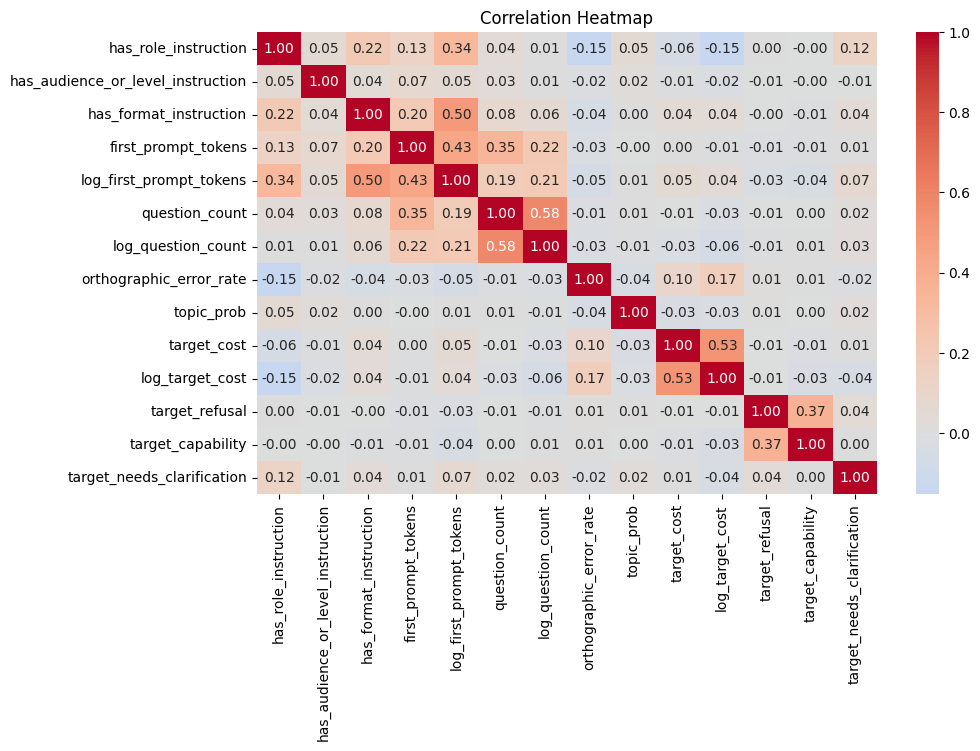

In [ ]:
# ----------------------------
# CORRELATIONS
# ----------------------------

features_for_corr = binary_features + numeric_features + targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

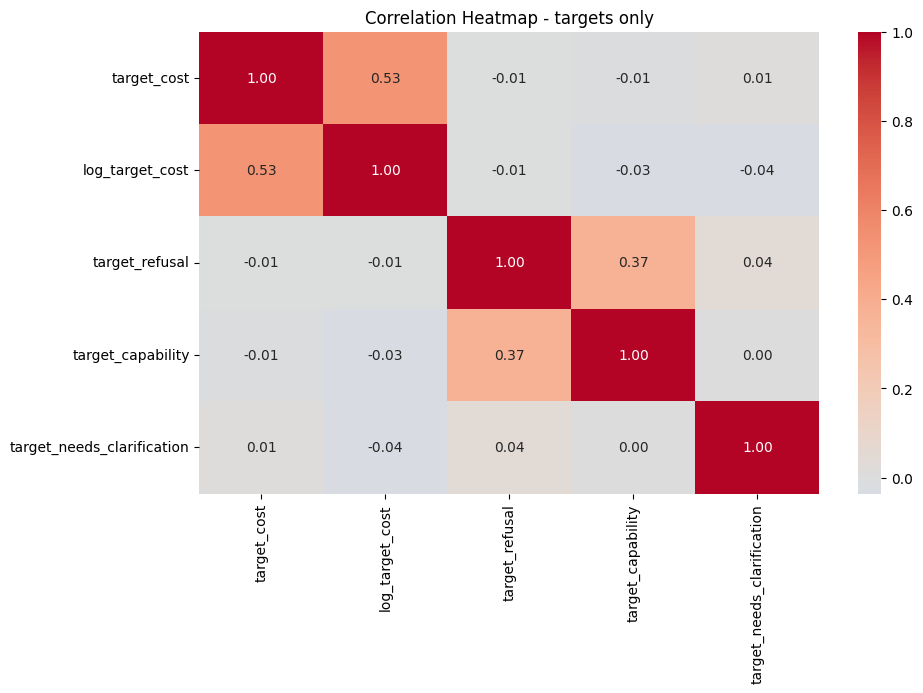

In [ ]:
features_for_corr = targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - targets only")
plt.show()

In [ ]:
# Train test split for "target_refusal"

x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_refusal"]
)

# Embedding novelty

centroid = x_train_emb.mean(axis=0)

x_train_df["embedding_novelty"] = cosine_distances(
    x_train_emb,
    centroid.reshape(1, -1)
).flatten()

x_test_df["embedding_novelty"] = cosine_distances(
    x_test_emb,
    centroid.reshape(1, -1)
).flatten()

# Features selection

In [ ]:
# features selection v01 - Structural prompt features

FEATURES_SELECTED_v01 = {
    "cat": [],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v02 -  Structural + engineered semantic features
  
FEATURES_SELECTED_v02 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v03 - Structural + engineered semantic features + dense embeddings

embedding_cols = [
    f"embedding_{i}" for i in range(x_train_emb.shape[1])
]

df_emb_train = pd.DataFrame(
    x_train_emb,
    columns=embedding_cols,
    index=x_train_df.index
)

df_emb_test = pd.DataFrame(
    x_test_emb,
    columns=embedding_cols,
    index=x_test_df.index
)

x_train_full = pd.concat(
    [x_train_df, df_emb_train],
    axis=1
)

x_test_full = pd.concat(
    [x_test_df, df_emb_test],
    axis=1
)

FEATURES_SELECTED_v03 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": embedding_cols
}

FEATURES_SELECTIONS = {
    "v01": FEATURES_SELECTED_v01,
    "v02": FEATURES_SELECTED_v02,
    "v03": FEATURES_SELECTED_v03,
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# Baseline model: logistic regression for "target_refusal"

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def original_feature_name(feature):

    # numeric features
    for col in features["num"]:
        if feature == f"num__{col}":
            return col

    # binary features
    for col in features["bin"]:
        if feature == f"bin__{col}":
            return col

    # categorical features (OHE)
    for col in features["cat"]:
        if feature.startswith(f"cat__{col}_"):
            return col

       # embeddings
    for col in features.get("emb", []):
        if feature.startswith(f"emb__{col}"):
            return "embeddings"

    return feature


for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
        features.get("num", [])
        + features.get("emb", [])
        + features.get("bin", [])
        + features.get("cat", [])
    )

    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_refusal"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_refusal"]
        )

    # predict test
    target_refusal_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_refusal_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )

    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
    fi_shap
    .groupby("original_feature")
    .agg(
        importance_sum=("importance", "sum"),
        importance_mean=("importance", "mean"),
        n_dimensions=("importance", "count")
    )
    .sort_values("importance_sum", ascending=False)
    )

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_refusal"], target_refusal_test_proba))
    print("f1_score:", f1_score(x_test_df["target_refusal"], target_refusal_test_pred))
    print("Precision:", precision_score(x_test_df["target_refusal"], target_refusal_test_pred))
    print("Recall:", recall_score(x_test_df["target_refusal"], target_refusal_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.5541813517370353
F1: 0.048973623138804316
Precision: 0.025561300909049223
Recall: 0.582905617336755
##########
Final Test Metrics
ROC AUC: 0.5639252660076812
f1_score: 0.048958122597612785
Precision: 0.025565180646524403
Recall: 0.5761904761904761
                                  feature  coefficient  abs_coef
4  bin__has_audience_or_level_instruction        -0.38      0.38
3               bin__has_role_instruction         0.35      0.35
0            num__log_first_prompt_tokens        -0.28      0.28
5             bin__has_format_instruction         0.18      0.18
2            num__orthographic_error_rate         0.08      0.08
1                 num__log_question_count        -0.03      0.03
                                   importance_sum  importance_mean  \
original_feature                                                     
log_first_prompt_tokens                      0.22             0.22   
has_role_instruction                

# Analysis Summary

## Objective
Predict whether an LLM response contains a refusal pattern based on prompt characteristics.

## Defined target
```python
refusal_pattern = (
    r"(i\s+cannot"
    r"|i\s+can't"
    r"|i\s+do\s+not\s+have\s+access"
    r"|i\s+don't\s+have\s+access"
    r"|i['’]?m\s+sorry.*?(cannot|can't)"
    r"|as\s+an\s+ai\s+language\s+model.*?(cannot|can't))"
)
df["target_no_refusal"] = (
    ~df["first_response"].fillna("").str.contains(refusal_pattern, regex=True)
).astype(int)

df["target_refusal"] = 1 - df["target_no_refusal"]

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.56 | 0.05 | log_first_prompt_tokens, has_role_instruction, has_format_instruction |
| v02 | 0.59 | 0.06 | topic_cat, task_type, log_first_prompt_tokens |
| v03 | 0.75 | 0.09 | embeddings, topic_cat, embedding_novelty |


# Baseline model: logistic regression for "target_capability"

In [ ]:
# Train test split for "target_capability"
 
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split( 
    df, embeddings, 
    test_size=0.2, 
    random_state=42, 
    stratify=df["target_capability"] )


# Embedding novelty

centroid = x_train_emb.mean(axis=0)

x_train_df["embedding_novelty"] = cosine_distances(
    x_train_emb,
    centroid.reshape(1, -1)
).flatten()

x_test_df["embedding_novelty"] = cosine_distances(
    x_test_emb,
    centroid.reshape(1, -1)
).flatten()

# Logistic regression modell "target_capability"

In [ ]:
for version, features in FEATURES_SELECTIONS.items():

    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_capability"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    if "emb" in features:
        x_train = x_train_full
        x_test = x_test_full
    else:
        x_train = x_train_df
        x_test = x_test_df

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_capability"]
        )

    # predict test
    target_capability_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_capability_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )


    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
        fi_shap
        .groupby("original_feature")
        .agg(
            importance_sum=("importance", "sum"),
            importance_mean=("importance", "mean"),
            n_dimensions=("importance", "count")
        )
        .sort_values("importance_sum", ascending=False)
        )
 

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_capability"], target_capability_test_proba))
    print("f1_score:", f1_score(x_test_df["target_capability"], target_capability_test_pred))
    print("Precision:", precision_score(x_test_df["target_capability"], target_capability_test_pred))
    print("Recall:", recall_score(x_test_df["target_capability"], target_capability_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.5212933221701247
F1: 0.021390169369017963
Precision: 0.010910192048799621
Recall: 0.5441225441225441
##########
Final Test Metrics
ROC AUC: 0.6216027006741589
f1_score: 0.027528675703858186
Precision: 0.0140485312899106
Recall: 0.6804123711340206
                                  feature  coefficient  abs_coef
5             bin__has_format_instruction         0.24      0.24
3               bin__has_role_instruction         0.23      0.23
0            num__log_first_prompt_tokens        -0.21      0.21
4  bin__has_audience_or_level_instruction        -0.09      0.09
2            num__orthographic_error_rate         0.05      0.05
1                 num__log_question_count        -0.01      0.01
                                   importance_sum  importance_mean  \
original_feature                                                     
log_first_prompt_tokens                      0.17             0.17   
has_format_instruction               

# Analysis Summary

## Objective
Predict whether a response from a large language model (LLM) contains a response pattern that expresses rejection due to a lack of capability.

## Defined target
```python
capability_pattern = (
    r"(i\s+(do\s+not|don't)\s+have\s+access"
    r"|i\s+cannot\s+access"
    r"|i\s+cannot\s+browse"
    r"|i\s+cannot\s+interact"
    r"|i\s+cannot\s+connect"
    r"|i\s+cannot\s+directly\s+"
    r"|i\s+do\s+not\s+have\s+the\s+ability\s+to"
    r"|i\s+don't\s+have\s+the\s+ability\s+to"
    r"|i\s+am\s+unable\s+to\s+)"
)

df["target_no_capability"] = (
    ~df["clean_response"]
    .fillna("")
    .str.contains(
        capability_pattern,
        regex=True,
        case=False
    )
).astype(int)

df["target_capability"] = 1 - df["target_no_capability"]

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.62 | 0.03 | log_first_prompt_tokens, has_format_instruction, has_role_instruction |
| v02 | 0.61 | 0.03 | topic_cat, task_type, log_first_prompt_tokens |
| v03 | 0.71 | 0.05 | embeddings, embedding_novelty, task_type |

# Train test split for "target_needs_clarification"

In [ ]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split( 
    df, embeddings, 
    test_size=0.2, 
    random_state=42, 
    stratify=df["target_needs_clarification"] )


# centroid only from training embeddings
centroid = x_train_emb.mean(axis=0)

# calculate novelty
x_train_df["embedding_novelty"] = cosine_distances(
    x_train_emb,
    centroid.reshape(1, -1)
).flatten()

x_test_df["embedding_novelty"] = cosine_distances(
    x_test_emb,
    centroid.reshape(1, -1)
).flatten()

# Basline model: Logistic regression for "target_needs_clarification"

In [ ]:
for version, features in FEATURES_SELECTIONS.items():

    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", "passthrough", features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_needs_clarification"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print(version)
    print("##########")
    print("Cross Validation Metrics")
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_needs_clarification"]
        )

    # predict test
    target_needs_clarification_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_needs_clarification_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)
    coef_df["abs_coef"] = coef_df["coefficient"].abs()

    coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    )

    # SHAP    

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
    fi_shap
    .groupby("original_feature")
    .agg(
        importance_sum=("importance", "sum"),
        importance_mean=("importance", "mean"),
        n_dimensions=("importance", "count")
    )
    .sort_values("importance_sum", ascending=False)
    )
 

    # metrics
    print("##########")
    print("Final Test Metrics")
    print("ROC AUC:", roc_auc_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_proba))
    print("f1_score:", f1_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print("Precision:", precision_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print("Recall:", recall_score(x_test_df["target_needs_clarification"], target_needs_clarification_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

v01
##########
Cross Validation Metrics
ROC AUC: 0.5013533199927711
F1: 0.22915803704000282
Precision: 0.14603538523683532
Recall: 0.5349268068743894
##########
Final Test Metrics
ROC AUC: 0.48626488223339237
f1_score: 0.21934037784181876
Precision: 0.13979591836734695
Recall: 0.5089153046062407
                                  feature  coefficient  abs_coef
4  bin__has_audience_or_level_instruction         0.09      0.09
0            num__log_first_prompt_tokens        -0.03      0.03
3               bin__has_role_instruction         0.02      0.02
5             bin__has_format_instruction         0.02      0.02
2            num__orthographic_error_rate         0.02      0.02
1                 num__log_question_count        -0.01      0.01
                                   importance_sum  importance_mean  \
original_feature                                                     
log_first_prompt_tokens                      0.03             0.03   
orthographic_error_rate               

# Analysis Summary

## Objective
Predict whether a response from a large language model (LLM) contains a question.

## Defined target
```python
clarification_pattern = r"(?i)(could you clarify|do you mean|can you specify|i'm not sure|i may have misunderstood|did you mean)"
question_pattern = r"\?"

df["target_needs_clarification"] = (
    df["first_response"].fillna("").str.contains(clarification_pattern, regex=True)
    | (
        df["first_response"].fillna("").str.contains(question_pattern, regex=True)
        & df["first_response"].fillna("").str.len().gt(20)
    )
).astype(int)

```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 | Top3 most important features [SHAP]|
|---|---:|---:|---:|
| v01 | 0.49 | 0.22 | log_first_prompt_tokens, orthographic_error_rate, log_question_count |
| v02 | 0.49 | 0.22 | task_type, topic_cat, log_first_prompt_tokens |
| v03 | 0.49 | 0.21 | embeddings, topic_cat, task_type |


# Results of logistic regression

Overall, logistic regression showed only limited predictive power: While the inclusion of embeddings significantly improved the ROC-AUC for refusal patterns (from 0.56 to 0.75) and capability-related responses (from 0.62 to 0.71), performance in detecting clarification questions remained at random levels (ROC-AUC ≈ 0.49).

# Train test split for "log_target_cost"

In [ ]:
df["target_bin"] = pd.qcut(
    df["log_target_cost"],
    q=10,
    labels=False
)

x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_bin"]
)

x_train_df = x_train_df.drop(columns=["target_bin"])
x_test_df = x_test_df.drop(columns=["target_bin"])


# centroid only from training embeddings
centroid = x_train_emb.mean(axis=0)

# calculate novelty
x_train_df["embedding_novelty"] = cosine_distances(
    x_train_emb,
    centroid.reshape(1, -1)
).flatten()

x_test_df["embedding_novelty"] = cosine_distances(
    x_test_emb,
    centroid.reshape(1, -1)
).flatten()

# Linear regression modell "log_target_cost"

In [ ]:
best_pipelines = {}
best_alphas = {}
best_scores = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.1, 1, 10, 100]

for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
    features.get("num", [])
    + features.get("emb", [])
    + features.get("bin", [])
    + features.get("cat", [])
    )

    transformers = []
    if features.get("num", []):
        transformers.append(("num", StandardScaler(), features["num"]))
    if features.get("emb", []):
        transformers.append(("emb", StandardScaler(), features["emb"]))
    if features.get("bin", []):
        transformers.append(("bin", "passthrough", features["bin"]))
    if features.get("cat", []):
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features["cat"]))


    # preprocess
    
    preprocess = ColumnTransformer(transformers=transformers)

    best_r2 = -np.inf
    best_alpha = None
    best_pipeline = None

    for alpha in alphas:
        pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", Ridge(alpha=alpha))
        ])

        results = cross_validate(
            pipeline,
            x_train_full[features_cols],
            x_train_df["log_target_cost"],
            cv=cv,
            scoring=["r2", "neg_mean_absolute_error"]
        )

        mean_r2 = results["test_r2"].mean()

        #print("##########")
        print(version, "alpha:", alpha, "R²:", mean_r2)

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_alpha = alpha
            best_pipeline = pipeline


    # fit model with best alpha
    best_pipeline.fit(x_train_full[features_cols], x_train_df["log_target_cost"])
    best_pipelines[version] = best_pipeline
    best_alphas[version] = best_alpha
    best_scores[version] = best_r2

    print(version)
    print("Best alpha:", best_alpha)
    print("Best CV R²:", best_r2)
    print("################")


    # SHAP 

for version in ["v01", "v02", "v03"]:
    features = FEATURES_SELECTIONS[version]
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    pipeline = best_pipelines[version]
    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    }).sort_values("coefficient", ascending=False)


    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(model, features_train_transformed)
    shap_values = explainer(features_test_transformed)

    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)

    fi_shap["original_feature"] = fi_shap["feature"].apply(original_feature_name)
    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    print(version)
    display(coef_df.head(40))
    display(grouped_importance)

v01 alpha: 0.1 R²: -0.00039846861325705253
v01 alpha: 1 R²: -0.0003973825250187524
v01 alpha: 10 R²: -0.00038727793628106076
v01 alpha: 100 R²: -0.00032936815115740535
v01
Best alpha: 100
Best CV R²: -0.00032936815115740535
################
v02 alpha: 0.1 R²: -0.0006772474217579871
v02 alpha: 1 R²: -0.0006756824342046385
v02 alpha: 10 R²: -0.0006609121985298172
v02 alpha: 100 R²: -0.0005655744317563771
v02
Best alpha: 100
Best CV R²: -0.0005655744317563771
################
v03 alpha: 0.1 R²: -0.016131732826471224
v03 alpha: 1 R²: -0.016125186259557278
v03 alpha: 10 R²: -0.01606187361796798
v03 alpha: 100 R²: -0.015547006551539644
v03
Best alpha: 100
Best CV R²: -0.015547006551539644
################
v01


,feature,coefficient
4,bin__has_audience_or_level_instruction,0.06
5,bin__has_format_instruction,0.01
1,num__log_question_count,-0.00
0,num__log_first_prompt_tokens,-0.00
2,num__orthographic_error_rate,-0.01
3,bin__has_role_instruction,-0.04


,original_feature,importance
2,has_role_instruction,0.01
5,orthographic_error_rate,0.01
1,has_format_instruction,0.00
3,log_first_prompt_tokens,0.00
4,log_question_count,0.00
0,has_audience_or_level_instruction,0.00


v02


,feature,coefficient
6,bin__has_audience_or_level_instruction,0.06
15,cat__task_type_translation,0.03
19,cat__topic_cat_noise,0.03
18,cat__topic_cat_general,0.02
8,cat__task_type_brainstorming,0.01
20,cat__topic_cat_technical,0.01
7,bin__has_format_instruction,0.01
11,cat__task_type_explanation,0.01
2,num__embedding_novelty,0.00
9,cat__task_type_coding,0.00


,original_feature,importance
8,topic_cat,0.03
3,has_role_instruction,0.01
7,task_type,0.01
6,orthographic_error_rate,0.01
2,has_format_instruction,0.00
0,embedding_novelty,0.00
9,topic_prob,0.00
5,log_question_count,0.00
4,log_first_prompt_tokens,0.00
1,has_audience_or_level_instruction,0.00


v03


,feature,coefficient
390,bin__has_audience_or_level_instruction,0.06
273,emb__embedding_268,0.03
247,emb__embedding_242,0.03
399,cat__task_type_translation,0.03
68,emb__embedding_63,0.03
305,emb__embedding_300,0.03
383,emb__embedding_378,0.03
63,emb__embedding_58,0.03
335,emb__embedding_330,0.03
376,emb__embedding_371,0.03


,original_feature,importance
1,embeddings,2.88
8,task_type,0.02
9,topic_cat,0.01
4,has_role_instruction,0.01
5,log_first_prompt_tokens,0.01
10,topic_prob,0.00
6,log_question_count,0.00
7,orthographic_error_rate,0.00
2,has_audience_or_level_instruction,0.00
3,has_format_instruction,0.00


# Analysis Summary

## Objective
Predict how much costs are influenced by prompt characteristics.

## Defined Target
```python
log_target_cost = log(first_response_tokens)
```
## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Ridge regression showed no significant predictive power for the logarithmic costs across all feature sets (R2 scores ranging from −0.0003 to −0.0155); in particular, the embeddings did not improve model performance, even though they had the highest aggregated importance in the SHAP analysis.